### Titanic Classification
- Problem Statement : predict if travller is survived on titanic

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

In [2]:
df = pd.read_csv('titanic.csv')
df.head()

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO"
1,1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON"
2,1,0,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1,2,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON"
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"


### EDA

In [3]:
df.drop(['name','home.dest'],inplace=True,axis=1)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 12 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   pclass    1309 non-null   int64  
 1   survived  1309 non-null   int64  
 2   sex       1309 non-null   object 
 3   age       1046 non-null   float64
 4   sibsp     1309 non-null   int64  
 5   parch     1309 non-null   int64  
 6   ticket    1309 non-null   object 
 7   fare      1308 non-null   float64
 8   cabin     295 non-null    object 
 9   embarked  1307 non-null   object 
 10  boat      486 non-null    object 
 11  body      121 non-null    float64
dtypes: float64(3), int64(4), object(5)
memory usage: 122.8+ KB


In [5]:
df.isna().sum()

pclass         0
survived       0
sex            0
age          263
sibsp          0
parch          0
ticket         0
fare           1
cabin       1014
embarked       2
boat         823
body        1188
dtype: int64

In [6]:
# To handel the Missing Values
# delete the rows having missing values
    # - when no of columns in row are missing 
# delete the columns having missing values
    # - when most values (>50) are missing
# impute/replace the misssing values with mean median or mode
# Stander option when less no. of values are missing in column

In [7]:
# Most of the values are missing from the cabin boat and body
# Since ticket and fair col similar to pclass so delete them

In [8]:
df.drop(['body','boat','cabin','ticket','fare'],axis=1,inplace=True)

In [9]:
# less values in the age column so impute them

In [10]:
df['age'] = df['age'].fillna(df['age'].mean())

In [11]:
# Find the Mode for embarked column
mode = df['embarked'].mode()[0]
#Replace the missing values in embarked columns with the mode value
df['embarked'] = df['embarked'].fillna(mode)

In [12]:
df.isnull().sum()

pclass      0
survived    0
sex         0
age         0
sibsp       0
parch       0
embarked    0
dtype: int64

In [13]:
# convert embarked data to the numric
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
encoder.fit(df['embarked'])
df['embarked'] = encoder.transform(df['embarked'])

In [14]:
encoder_p = LabelEncoder()
encoder_p.fit(df['pclass'])
df['pclass'] = encoder_p.transform(df['pclass'])

In [15]:
encoder_s = LabelEncoder()
encoder_s.fit(df['sex'])
df['sex'] = encoder_s.transform(df['sex'])

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   pclass    1309 non-null   int64  
 1   survived  1309 non-null   int64  
 2   sex       1309 non-null   int64  
 3   age       1309 non-null   float64
 4   sibsp     1309 non-null   int64  
 5   parch     1309 non-null   int64  
 6   embarked  1309 non-null   int64  
dtypes: float64(1), int64(6)
memory usage: 71.7 KB


In [17]:
#check if data imbalanced
df['survived'].value_counts()

survived
0    809
1    500
Name: count, dtype: int64

Text(0.5, 1.0, 'Survived Status')

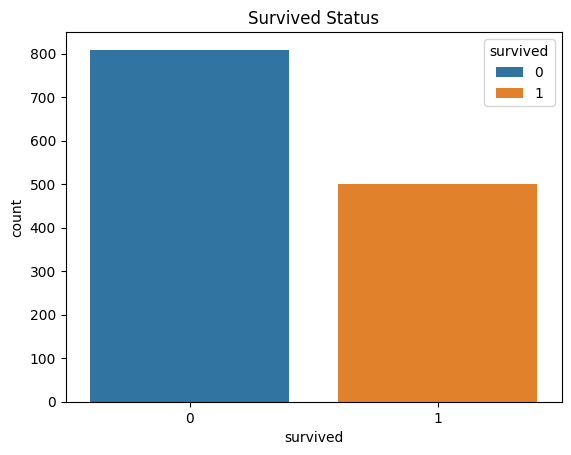

In [18]:
sns.countplot(x='survived',hue='survived',data=df)
plt.title('Survived Status')

<Axes: xlabel='sex', ylabel='count'>

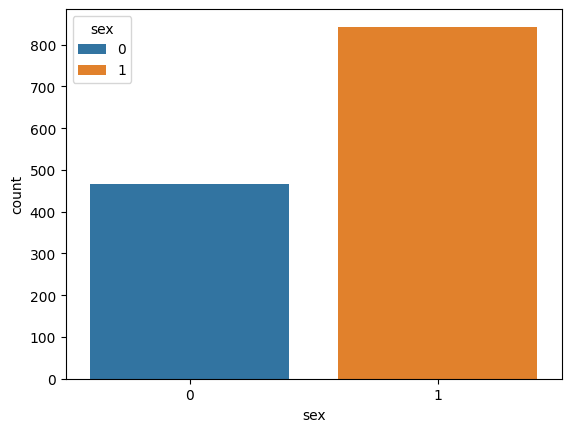

In [19]:
#check the travellers with genders
sns.countplot(x='sex',hue='sex',data=df)  #female=0 male=1

<Axes: xlabel='sex', ylabel='count'>

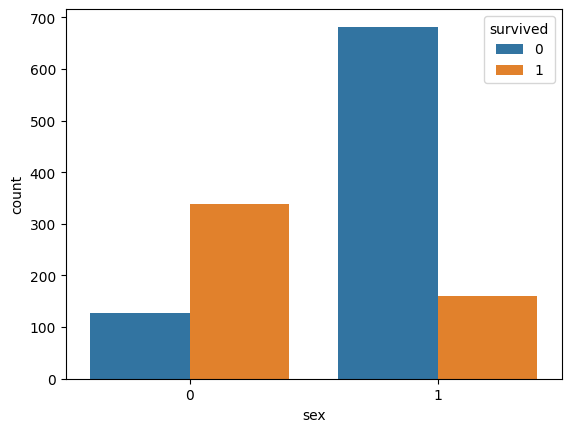

In [20]:
sns.countplot(x='sex',hue='survived',data=df)
##female survived more than men 

<Axes: xlabel='pclass', ylabel='count'>

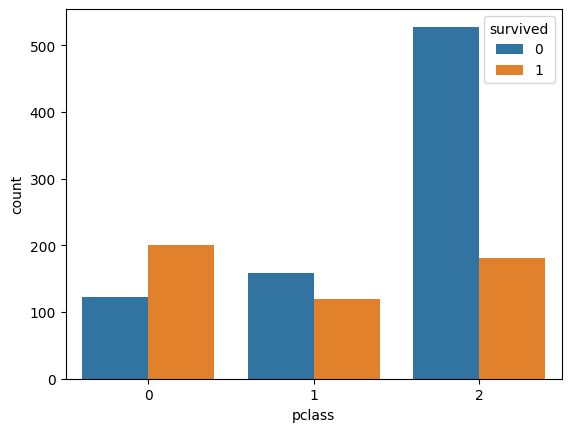

In [21]:
sns.countplot(x='pclass',hue='survived',data=df)

<Axes: xlabel='age', ylabel='count'>

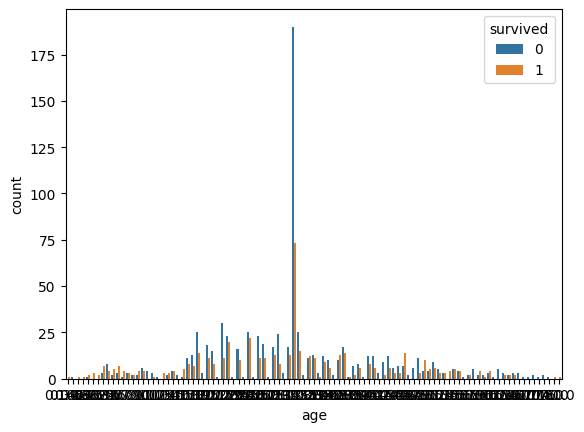

In [22]:
sns.countplot(x='age',hue='survived',data=df)

In [23]:
#perfor correlation
df.corr()['survived']

pclass     -0.312469
survived    1.000000
sex        -0.528693
age        -0.050199
sibsp      -0.027825
parch       0.082660
embarked   -0.175313
Name: survived, dtype: float64

In [24]:
df.describe()

,pclass,survived,sex,age,sibsp,parch,embarked
count,1309.000000,1309.000000,1309.000000,1309.000000,1309.000000,1309.000000,1309.000000
mean,1.294882,0.381971,0.644003,29.881135,0.498854,0.385027,1.493506
std,0.837836,0.486055,0.478997,12.883199,1.041658,0.865560,0.814244
min,0.000000,0.000000,0.000000,0.166700,0.000000,0.000000,0.000000
25%,1.000000,0.000000,0.000000,22.000000,0.000000,0.000000,1.000000
50%,2.000000,0.000000,1.000000,29.881135,0.000000,0.000000,2.000000
75%,2.000000,1.000000,1.000000,35.000000,1.000000,0.000000,2.000000
max,2.000000,1.000000,1.000000,80.000000,8.000000,9.000000,2.000000


### Data prepration

In [25]:
x=df.drop(['survived','age','sibsp','parch'],axis=1)
y=df['survived']

In [26]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,train_size=0.7,random_state=42)

### Train The Model

In [41]:
from sklearn.linear_model import LogisticRegressionCV
def create_logistic_model():
    model = LogisticRegressionCV()
    model.fit(x_train,y_train)
    return model

In [42]:
from sklearn.naive_bayes import GaussianNB
def create_naive_model():
    model = GaussianNB()
    model.fit(x_train,y_train)
    return model

In [43]:
from sklearn.neighbors import KNeighborsClassifier
def create_knn_model():
    model = KNeighborsClassifier()
    model.fit(x_train,y_train)
    return model

In [57]:
from sklearn.svm import SVC
def create_SVM_model():
    model = SVC(kernel='linear')
    model.fit(x_train,y_train)
    return model

### Ealuate Models

In [58]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score
def evaluate_model(model_name,model,x,y):
    #predict the values
    y_pred = model.predict(x)
    accuracy = accuracy_score(y,y_pred)
    preision = precision_score(y,y_pred)
    recall = recall_score(y,y_pred)
    f1 = f1_score(y,y_pred)
    return model_name,accuracy,preision,recall,f1

In [59]:
model_lr = create_logistic_model()
model_nb = create_naive_model()
model_knn = create_knn_model()
model_svm = create_SVM_model()


C:\Users\Hp\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:2092: FutureWarning: The default value for l1_ratios will change from None to (0.0,) in version 1.10. From version 1.10 onwards, only array-like with values in [0, 1] will be allowed, None will be forbidden. To avoid this warning, explicitly set a value, e.g. l1_ratios=(0,).
  warnings.warn(
C:\Users\Hp\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:2137: FutureWarning: The default value of the parameter 'scoring' will change from None, i.e. accuracy, to 'neg_log_loss' in version 1.11. To silence this warning, explicitly set the scoring parameter: scoring='neg_log_loss' for the new, scoring='accuracy' or scoring=None for the old default.
  warnings.warn(
C:\Users\Hp\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:2150: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplifie

In [60]:
models = [
    {"name":"Logistic regression","model":model_lr},
    {"name":"Naive Bayes","model":model_nb},
    {"name":"KNN ","model":model_knn},
    {"name":"SVM","model":model_svm}
]

In [61]:
training_metrics=[]
for info in models:
    training_metrics.append(evaluate_model(info['name'],info['model'],x_train,y_train))
pd.DataFrame(training_metrics,columns = ['ALGO','accuracy','Priecision','Recall','f1'])

,ALGO,accuracy,Priecision,Recall,f1
0,Logistic regression,0.799127,0.765343,0.640483,0.697368
1,Naive Bayes,0.766376,0.656836,0.740181,0.696023
2,KNN,0.796943,0.803347,0.580060,0.673684
3,SVM,0.776201,0.694444,0.679758,0.687023


In [62]:
# Testing metrics 
testing_metrics=[]
for info in models:
    testing_metrics.append(evaluate_model(info['name'],info['model'],x_test,y_test))
pd.DataFrame(testing_metrics,columns = ['ALGO','accuracy','Priecision','Recall','f1'])

,ALGO,accuracy,Priecision,Recall,f1
0,Logistic regression,0.768448,0.800000,0.615385,0.695652
1,Naive Bayes,0.776081,0.748466,0.721893,0.734940
2,KNN,0.748092,0.812500,0.538462,0.647687
3,SVM,0.788804,0.802817,0.674556,0.733119
